In [1]:
# analyze the static qpos of the robotic leg, 
# only take consideratoin of the interior working area
import pandas as pd
import matplotlib.pyplot as plt
import datetime

Text(0.5, 1.0, 'Pressure vs Original Rank')

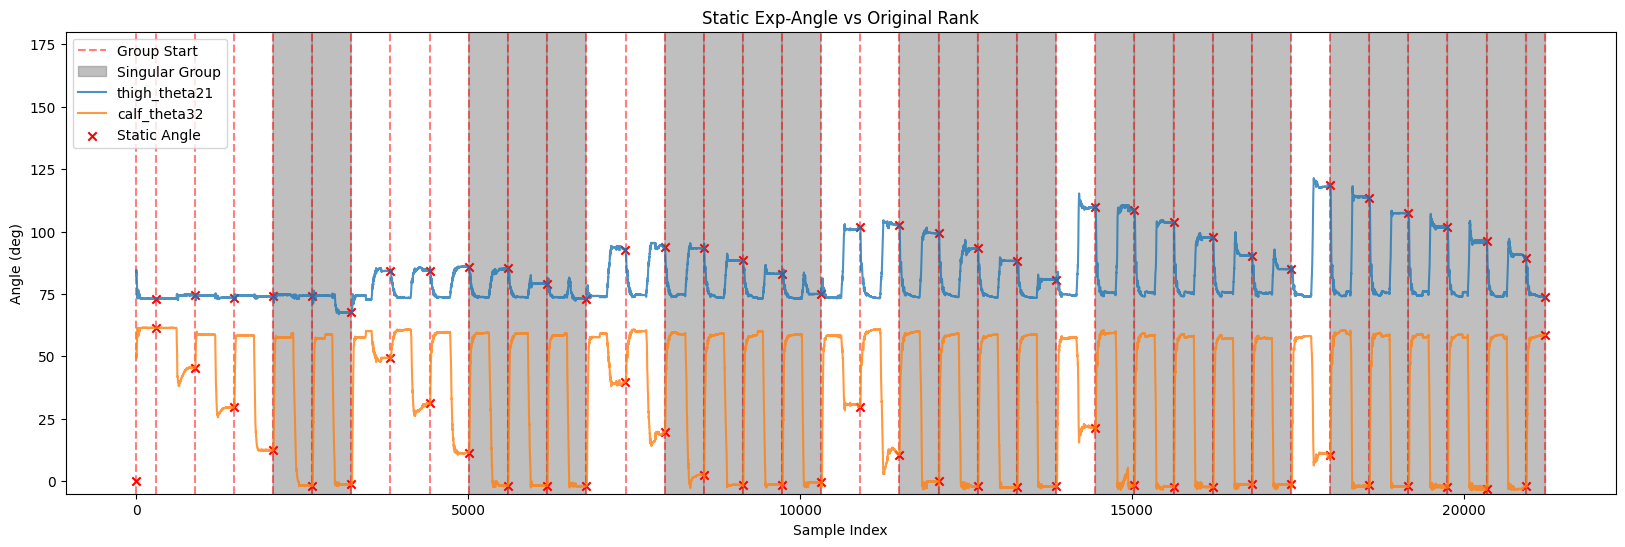

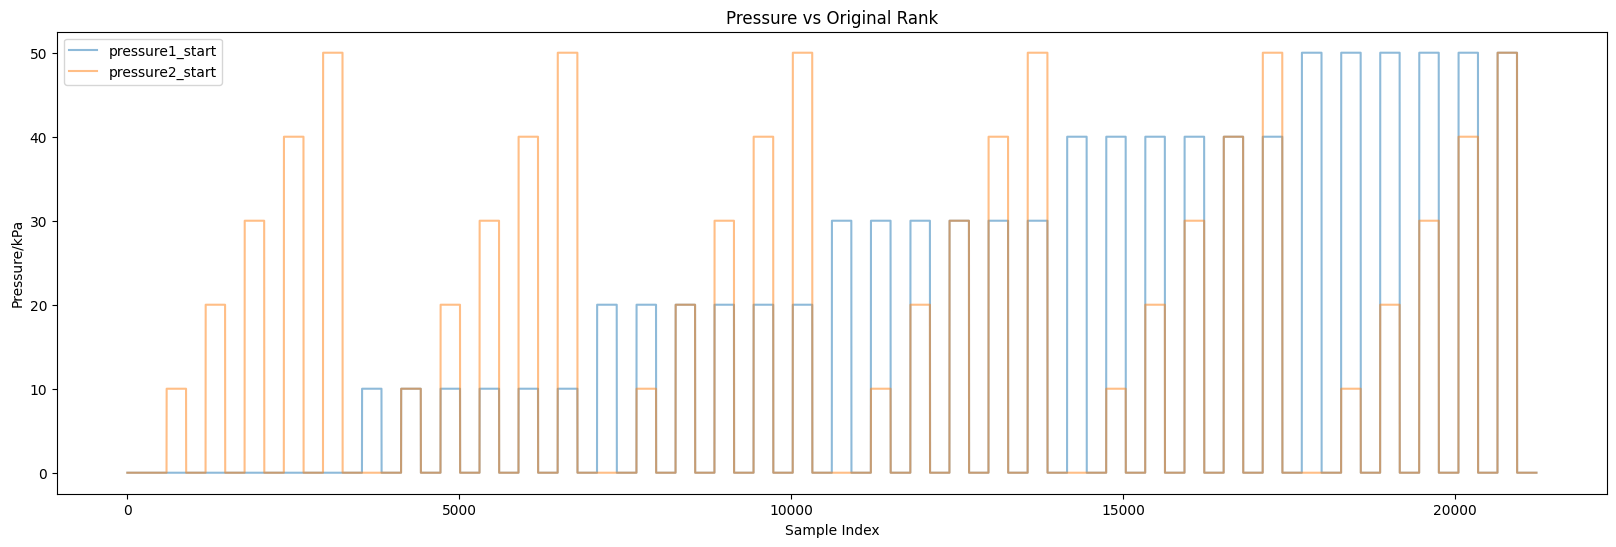

In [2]:
data = pd.read_csv('./dynamic/data/ToCenter_2025-02-20_21-06-20_A2B_data.csv')

# plot the theta-index Figure
plt.figure(figsize=(20, 6))

# find start index of each group
start_index = [0]
end_index = []
effective_group_index = []      # valid experiment group indices (group number, starting from 0)
for i in range(1, len(data['relative_time'])):
    # For to-center data, the pressure is from [target val, target val] to [0, 0]. Step happens at 5 s
    if (data['relative_time'][i]>5 and data['relative_time'][i-1]<5):
        start_index.append(i)
        end_index.append(i-1)
end_index.append(len(data['relative_time'])-1)

# show start time in plot
for i in start_index:
    plt.axvline(x=i, color='r', linestyle='--', alpha=0.5)
plt.axvline(x=len(data['relative_time']), color='r', linestyle='--', alpha=0.5, label="Group Start")

# for data['calf_theta32'] near 0 Group, plot gray of that group
for i in range(0, len(start_index)):
    if data['calf_theta32'][end_index[i]] < 5:
        plt.fill_between(range(start_index[i], end_index[i]), -100, 200, color='gray', alpha=0.5)
    else:
        effective_group_index.append(i)
# the last group is set to [0, 0] as end state, which is not a valid group
effective_group_index.pop()
plt.fill_between(range(start_index[-1], len(data['relative_time'])-1), -100, 200, color='gray', alpha=0.5, label="Singular Group")

plt.plot(data['thigh_theta21'], alpha=0.8, label='thigh_theta21')
plt.plot(data['calf_theta32'], alpha=0.8, label='calf_theta32')

# plot the end point as the static angle
for i in end_index:
    plt.scatter(i, data['thigh_theta21'][i], c='r', marker='x')
    plt.scatter(i, data['calf_theta32'][i], c='r', marker='x')
# legend the end point
plt.scatter(0, 0, c='r', marker='x', label='Static Angle')


plt.legend()
plt.xlabel('Sample Index')
plt.ylabel('Angle (deg)')
plt.ylim(-5, 180)
plt.title('Static Exp-Angle vs Original Rank')

plt.figure(figsize=(20, 6))
# plt.plot(data['calf_theta32'], alpha=0.5)
# plt.plot(data['pressure1_start']/1000, alpha=0.5)
# plt.plot(data['pressure2_start']/1000, alpha=0.5)
plt.plot(data['current_pressure1']/1000, alpha=0.5)
plt.plot(data['current_pressure2']/1000, alpha=0.5)
plt.legend(['pressure1_start', 'pressure2_start', 'current_pressure1', 'current_pressure2'])
plt.xlabel('Sample Index')
plt.ylabel('Pressure/kPa')
plt.title('Pressure vs Original Rank')


In [3]:
effective_group_index

[0, 1, 2, 3, 6, 7, 8, 12, 13, 18, 19, 24, 30]

In [4]:
# Extract the final converged positions: (P1, P2, theta1, theta2)
# make the real static data for system identification

def record_static_data(mode):
    '''mode="all" or "effective"'''
    group_indices = range(len(start_index)-1) if mode=="all" else effective_group_index
    static_data = [
        {'P1 (kPa)': data['pressure1_start'][end_index[group_index]]/1000,
        'P2 (kPa)': data['pressure2_start'][end_index[group_index]]/1000,
        'theta1 (deg)': data['thigh_theta21'][end_index[group_index]],
        'theta2 (deg)': data['calf_theta32'][end_index[group_index]]}
        for group_index in group_indices
    ]
    return pd.DataFrame(static_data)

# save the static data of effective
static_data_effective = record_static_data(mode="effective")
print(static_data_effective)
static_data_effective.to_csv(f'./tmpdata/real(effective)_StaticPoint_6group_2025-02-21_08-55-07_{datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")}.csv', index=False, float_format='%.4f')
print(f"File name: real_{datetime.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}.csv")

# save the static data of all
static_data_effective = record_static_data(mode="all")
print(static_data_effective)
static_data_effective.to_csv(f'./tmpdata/real(all)_StaticPoint_6group_2025-02-21_08-55-07_{datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")}.csv', index=False, float_format='%.4f')
print(f"File name: real_{datetime.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}.csv")

    P1 (kPa)  P2 (kPa)  theta1 (deg)  theta2 (deg)
0        0.0       0.0     73.085190     61.388043
1        0.0      10.0     74.571501     45.422559
2        0.0      20.0     73.505703     29.565861
3        0.0      30.0     74.082223     12.355127
4       10.0       0.0     84.227968     49.436004
5       10.0      10.0     84.319702     31.192765
6       10.0      20.0     85.815752     11.413719
7       20.0       0.0     92.710274     39.854276
8       20.0      10.0     93.598822     19.699098
9       30.0       0.0    101.679652     29.749648
10      30.0      10.0    102.661385     10.554796
11      40.0       0.0    109.709639     21.441943
12      50.0       0.0    118.484964     10.312879


OSError: Cannot save file into a non-existent directory: 'tmpdata'